In [23]:
#packages
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import *

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

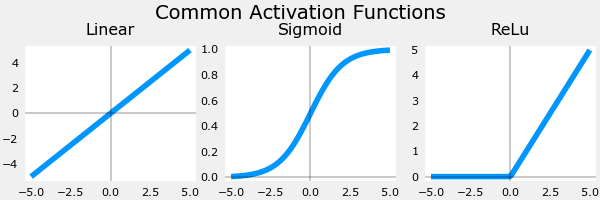

In [24]:
#Relu Activation
plt_act_trio()

In [25]:
#create a Numpy implementation
def my_softmax(z):
    ''' 
    Softmax converts a vector of values to a probability distribution

    Args:
     z (ndarray (N,)) : input data, N features
    
    Returns:
     a (ndarray (N,))  : softmax of z
    '''
    #ez = np.exp(z[j])
    #a = ez/np.sum(ez)
    N = len(z)
    a = np.zeros(N)   #initialize a to zeros
    ez_sum = 0   #initialize sum to zero
    for k in range(N):  #loop over number of outputs
        ez_sum += np.exp(z[k])  #sum exp(z[k]) to build the shared denominator
    for j in range(N):  #loop over number of outputs again
        a[j] = np.exp(z[j]) / ez_sum
    return(a)

In [26]:
z = np.array([1., 2., 3., 4. ])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f'my_softmax(z):         {a}')
print(f'tensorflow softmax(z): {atf}')

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]


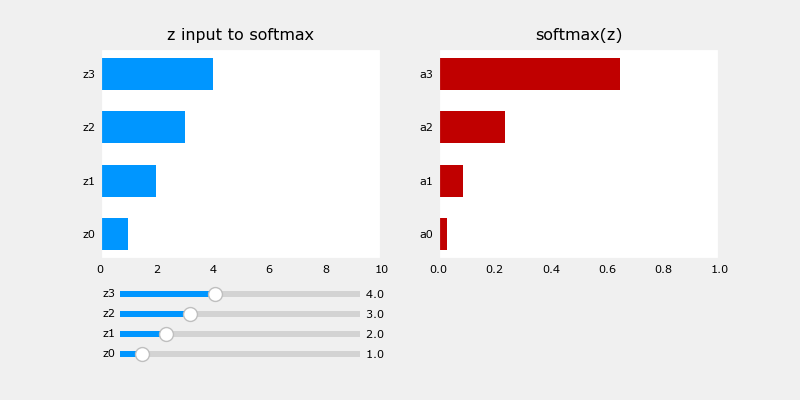

In [27]:
#observation - varying the values of z inputs. 
# The exponential in the enumerator magnifies small differences in the values
plt.close('all')
plt_softmax(my_softmax)

In [ ]:
#NEURAL NETWORKS
'''
Problem statement:

Using nn to recognize ten handwritten digits, 0-9
 This is a multiclass classification where one of the n choices
 is selected
 1. The data set contains 5000 training examples of handwritten digits 
     Each training example is a 20-pixel x 20-pixel grayscale image of the digit.
      Each pixel is represented by a floating-point number indicating the grayscale intensity at that location.
      The 20 by 20 grid of pixels is “unrolled” into a 400-dimensional vector.
      Each training examples becomes a single row in our data matrix X.
      This gives us a 5000 x 400 matrix X where every row is a training example of a handwritten digit image.
2. The second part of the training set is a 5000 x 1 dimensional vector y that contains labels for 
 the training set
    y = 0 if the image is of the digit 0, y = 4 if the image is of the digit 4 and so on.
'''

In [28]:
#dataset
X, y = load_data()

In [29]:
#view variables to get familiar with the dataset
print('The first element of X is: ', X[0])



The first element of X is:  [ 0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  8.56e-06  1.94e-06 -7.37e-04
 -8.13e-03 -1.86e-02 -1.87e-02 -1.88e-02 -1.91e-02 -1.64e-02 -3.78e-03
  3.30e-04  1.28e-05  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  1.16e-04  1.20e-04 -1.40e-02 -2.85e-02  8.04e-02
  2.67e-01  2.74e-01  2.79e-01  2.74e-01  2.25e-0

In [30]:
print('The first element of y is: ', y[0,0])
print('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


In [31]:
#check dimensions of the variables
print('The shape of X is :' + str(X.shape))
print('The shape of y is :' +str(y.shape))

The shape of X is :(5000, 400)
The shape of y is :(5000, 1)


In [ ]:
#visualize the data
#randomly select 64 rows from X, maps each row bachk to a 20 pixel by 20 pixel grayscaleimag
# and displays the images together
# The label for each image is displayed above the image

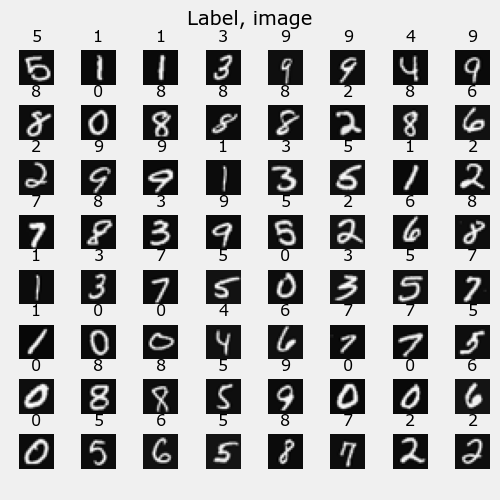

In [32]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(5,5))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.91]) #left, bottom, right, top

#fig.tight_layout(pad=0.5)
widgvis(fig)
for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding to the random indices and reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    #display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    #display the label above the image
    ax.set_title(y[random_index, 0])
    ax.set_axis_off()
    fig.suptitle('Label, image', fontsize=14)


In [42]:
#MODEL REPERESENTATION
#Tensorflow model implementation
tf.random.set_seed(1234)  #for consistent results
model = Sequential([
    tf.keras.Input(shape=(400,)),
    Dense(25, activation='relu', name='L1'),
    Dense(15, activation='relu', name='L2'),
    Dense(10, activation='linear', name='L3')
],
name = 'my_model'
)

In [43]:
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 25)                10025     
                                                                 
 L2 (Dense)                  (None, 15)                390       
                                                                 
 L3 (Dense)                  (None, 10)                160       
                                                                 
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________


In [44]:
#unit test
test_model(model, 10, 400)

NameError: name 'test_model' is not defined

In [45]:
#examine to ensure tensorflow produced the same dimensions
[layer1, layer2, layer3] = model.layers

In [46]:
#examine weights and shape
W1, b1 = layer1.get_weights()
W2, b2 = layer2.get_weights()
W3, b3 = layer3.get_weights()
print(f'W1 shape = {W1.shape}, b1 shape = {b1.shape}')
print(f'W2 shape = {W2.shape}, b2 shape = {b2.shape}')
print(f'W3 shape = {W3.shape}, b3 shape = {b3.shape}')


W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


In [47]:
#define loss unction
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X, y,
    epochs=40
)

Epoch 1/40
157/157 [==============================] - 1s 2ms/step - loss: 1.4319
Epoch 2/40
157/157 [==============================] - 0s 2ms/step - loss: 0.5609
Epoch 3/40
157/157 [==============================] - 0s 2ms/step - loss: 0.4025
Epoch 4/40
157/157 [==============================] - 0s 2ms/step - loss: 0.3410
Epoch 5/40
157/157 [==============================] - 0s 2ms/step - loss: 0.3054
Epoch 6/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2808
Epoch 7/40
157/157 [==============================] - 0s 3ms/step - loss: 0.2559
Epoch 8/40
157/157 [==============================] - 1s 4ms/step - loss: 0.2387
Epoch 9/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2246
Epoch 10/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2069
Epoch 11/40
157/157 [==============================] - 0s 2ms/step - loss: 0.1988
Epoch 12/40
157/157 [==============================] - 0s 2ms/step - loss: 0.1889
Epoch 13/40
157/157 [====

In [ ]:
#examine the loss in a plot
plot_loss_tf(history)

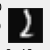

1/1 [==============================] - 0s 459ms/step
predicting a Two: 
[[ -7.68   2.94   5.92   2.21 -11.91  -3.71  -4.11   1.78  -3.79  -7.8 ]]
Largest Predcition index: 2


In [51]:
#prediction
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1, 400))  #prediction

print(f'predicting a Two: \n{prediction}')
print(f'Largest Predcition index: {np.argmax(prediction)}')

In [ ]:
#if the problem requires selection that's sufficient
#if the problem requires probability, softmax activation is required


In [52]:
#softmax activation
prediction_p = tf.nn.softmax(prediction)

print(f'prediciting a Two Probability vector: \n{prediction_p}')
print(f'Total of predictions: {np.sum(prediction_p):0.3f}')

prediciting a Two Probability vector: 
[[1.14e-06 4.63e-02 9.17e-01 2.24e-02 1.64e-08 5.99e-05 4.01e-05 1.46e-02
  5.55e-05 1.00e-06]]
Total of predictions: 1.000


In [53]:
#to return an integer
yhat = np.argmax(prediction_p)

print(f'np.argmax(prediction_p) : {yhat}')

np.argmax(prediction_p) : 2


1/1 [==============================] - 0s 33ms/step


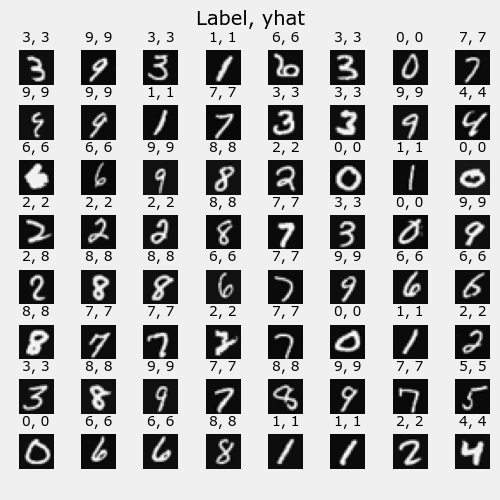

In [56]:
#compare predcitions vs labels
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13, rect=[0, 0.03, 1, 0.91])  #[left, bottom, right, top]
widgvis(fig)
for i, ax in enumerate(axes.flat):
    #select random indices
    random_index = np.random.randint(m)

    #select rows corresponding to the random indices and rechape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    #display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    #predict using the neural network
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)

    #display the label above the image
    ax.set_title(f'{y[random_index, 0]}, {yhat}', fontsize=10)
    ax.set_axis_off()
fig.suptitle('Label, yhat', fontsize=14)
plt.show()


1/1 [==============================] - 0s 26ms/step
40 errors out of 5000 images


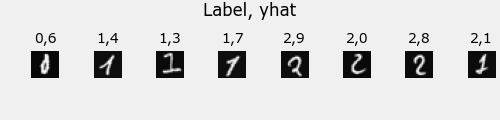

In [58]:
#some of the errors
print(f'{display_errors(model, X, y)} errors out of {len(X)} images')